In [2]:
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [3]:
shop_df=pd.read_pickle(r"D:\DataScience\GUVI\Local\Telangana_govt_Ration_distribution_clustering\feature_dataset.pkl")

In [4]:
#using only more meaningful features
features = [
    # Transaction behavior
    "avg_transactions",
    "transaction_cv",

    # Card utilization
    "avg_cards",
       
    # Portability
    "avg_portability",

    # Card-category composition
    "afsc_transaction_share",
    "fsc_transaction_share",
    "aap_transaction_share",

    # Financial activity
    "avg_amount"
]
#average commodity columns was excluded since most were zero

In [5]:
corr = shop_df[features].corr()

display(corr.round(2))

,avg_transactions,transaction_cv,avg_cards,avg_portability,afsc_transaction_share,fsc_transaction_share,aap_transaction_share,avg_amount
avg_transactions,1.00,-0.06,1.00,0.82,-0.26,0.32,-0.01,0.55
transaction_cv,-0.06,1.00,-0.06,0.17,0.00,0.03,-0.01,0.11
avg_cards,1.00,-0.06,1.00,0.82,-0.26,0.32,-0.01,0.55
avg_portability,0.82,0.17,0.82,1.00,-0.25,0.40,-0.00,0.68
afsc_transaction_share,-0.26,0.00,-0.26,-0.25,1.00,-0.47,0.04,-0.15
fsc_transaction_share,0.32,0.03,0.32,0.40,-0.47,1.00,0.01,0.38
aap_transaction_share,-0.01,-0.01,-0.01,-0.00,0.04,0.01,1.00,0.03
avg_amount,0.55,0.11,0.55,0.68,-0.15,0.38,0.03,1.00


Correlation Insights

Avg Transactions and Avg Cards (1.00): Perfect positive correlation indicates that shops with more ration cards generally have more transactions. 

Avg Transactions and Avg Portability (0.82): Strong positive correlation shows that high-transaction shops tend to handle more portability transactions, indicating potential portability hubs.

Avg Cards and Avg Portability (0.82): Shops with larger beneficiary bases also tend to have higher portability activity.

Avg Portability and Avg Amount (0.68): Shops with higher portability activity tend to have higher transaction amounts.

AFSC Share and FSC Share (-0.47): Moderate negative correlation indicates that a higher share of AFSC transactions is generally associated with a lower FSC share.

Transaction CV (-0.06 with Avg Transactions): Very weak correlation indicates that transaction volume and transaction variability are largely independent.

AAP Share: Shows almost no correlation with the other features, providing relatively independent information for clustering.


Overall Insight: High-volume shops tend to have more cards, higher portability activity, and higher transaction amounts.

In [6]:
#StandardScaler: because features have very different scales. Without scaling, large-value features can dominate clustering
# Select features
X = shop_df[features].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (17491, 8)
Scaled shape: (17491, 8)


In [7]:
#PCA: reduce the high-dimensional data to 2 dimensions

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(17491, 2)


In [8]:
#59% of the variation in your original features means variation is moderate and close to good for visualization
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.4460964  0.14457828]
Total explained variance: 0.5906746808916565


In [9]:
shop_df["PC1"] = X_pca[:, 0]
shop_df["PC2"] = X_pca[:, 1]

In [10]:
#K-means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

shop_df["cluster"] = kmeans.fit_predict(X_scaled)
#X_pca is not used because PCA is primarily being used here for visualization. X_scaled retain all your standardized behavioral features for clustering

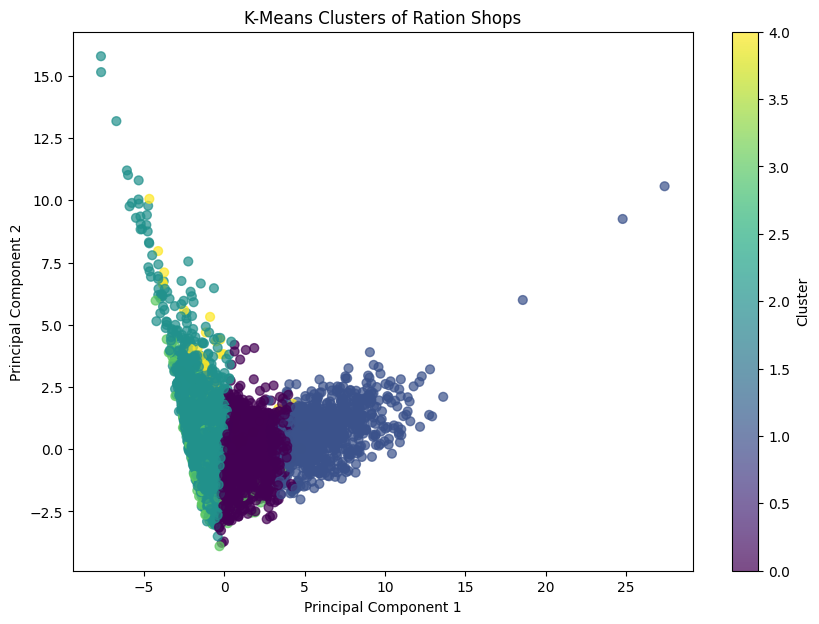

In [11]:
#Visualize K-Means clusters
plt.figure(figsize=(10, 7))

plt.scatter(
    shop_df["PC1"],
    shop_df["PC2"],
    c=shop_df["cluster"],
    cmap="viridis",
    s=40,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters of Ration Shops")
plt.colorbar(label="Cluster")

plt.show()

In [12]:
#DBSCAN to identify unusual shops
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

shop_df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

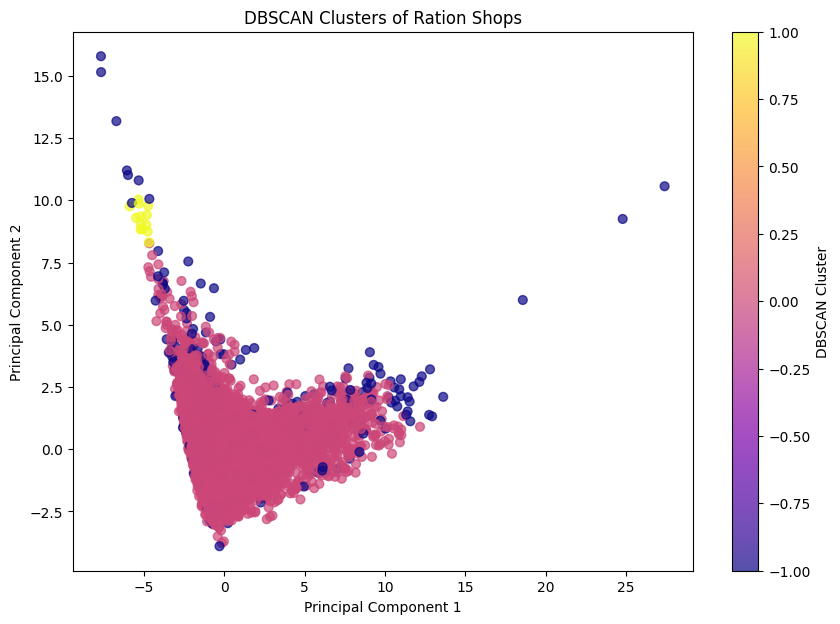

In [13]:
#visualize DBSCAN
plt.figure(figsize=(10, 7))

plt.scatter(
    shop_df["PC1"],
    shop_df["PC2"],
    c=shop_df["dbscan_cluster"],
    cmap="plasma",
    s=40,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters of Ration Shops")
plt.colorbar(label="DBSCAN Cluster")

plt.show()

In [14]:
kmeans_labels = kmeans.labels_
dbscan_labels = dbscan.labels_
print("K-Means cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nDBSCAN cluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

K-Means cluster counts:
0     5086
1     1009
2    10627
3      587
4      182
Name: count, dtype: int64

DBSCAN cluster counts:
-1      249
 0    17229
 1       13
Name: count, dtype: int64


Almost all shops belong to one dense group, while 249 shops are unusual/outliers.

DBSCAN looks almost identical to K-Means because PCA coordinates are exactly the same in both plots. It means plotting the same 17,491 shops at the same positions.

The difference is only the assignment:
-1 is Noise/outliers; 
0 is main cluster;
1 very small cluster.

In [15]:
#Profile the K-Means clusters-because cluster numbers themselves don't have meaning
cluster_profile = (
    shop_df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

display(cluster_profile)
print(shop_df["cluster"].value_counts().sort_index())

,avg_transactions,transaction_cv,avg_cards,avg_portability,afsc_transaction_share,fsc_transaction_share,aap_transaction_share,avg_amount
cluster,,,,,,,,
0,597.84,0.07,596.48,238.07,1.98,18.52,0.00,630.50
1,1135.86,0.11,1131.27,853.42,1.44,20.60,0.01,19902.99
2,317.31,0.06,316.48,54.22,3.16,16.98,0.00,36.83
3,244.35,0.42,243.45,152.66,2.80,17.47,0.00,1129.04
4,365.85,0.07,364.52,104.61,3.36,17.60,0.21,929.61


cluster
0     5086
1     1009
2    10627
3      587
4      182
Name: count, dtype: int64


### Cluster 0 → Stable High-Portability Shops

598 average transactions
CV = 0.07 → very stable
Portability = 238 → high compared with most clusters
5,086 shops

This is a substantial group of stable shops handling considerable portability activity.

### Cluster 1 → High-Volume Portability Hubs

This one is very distinctive:

1,136 transactions → highest
853 portability → highest by far
₹19,903 average amount → extremely high
CV = 0.11 → still relatively stable
1,009 shops

These are exactly the kind of shops one could call "Portability Hubs."

### Cluster 2 → Low-Volume Stable Shops

317 transactions
CV = 0.06 → lowest variation
Portability = 54 → lowest
₹36.83 average amount → very low
10,627 shops → largest cluster

This represents the dominant group of relatively stable, lower-activity shops.

### Cluster 3 → Highly Volatile Shops

This is the clearest one:

Only 244 transactions
CV = 0.42 → dramatically higher than every other cluster
587 shops

So "Highly Volatile Shops" is appropriate.

### Cluster 4 → Stable Medium-Volume Shops

366 transactions
CV = 0.07 → stable
Portability = 105 → moderate
AAP share = 0.21, highest among the clusters
182 shops

It's reasonable to call this Stable Medium-Volume Shops

In [16]:
cluster_names = {
    0: "Stable High-Portability Shops",
    1: "High-Volume Portability Hubs",
    2: "Low-Volume Stable Shops",
    3: "Highly Volatile Shops",
    4: "Stable Medium-Volume Shops"
}

shop_df["cluster_name"] = shop_df["cluster"].map(cluster_names)

In [17]:
#after creating features and cluster labels:
with open("shop_df.pkl", "wb") as f:
    pickle.dump(shop_df, f)

In [18]:
#standard scalar
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [19]:
#save pca
with open("pca.pkl", "wb") as f:
    pickle.dump(pca, f)

In [20]:
#save k-means
with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

In [21]:
#save DBSCAN
with open("dbscan.pkl", "wb") as f:
    pickle.dump(dbscan, f)

In [22]:
#features
with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

In [23]:
cluster_profile = (
    shop_df
    .groupby("cluster")[features]
    .mean()
)

with open("cluster_profile.pkl", "wb") as f:
    pickle.dump(cluster_profile, f)